Here I'll give a warning about Kernelized Stein methods. In high dimensions or with small particles sample they tend to underestimate posterior variance. This can lead to undesirable results. Moreover there is no single chance to check if inference was done good enough.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pymc3 as pm
import seaborn as sns
import scipy.stats as st
import theano
theano.config.compute_test_value = 'raise'
plt.matplotlib.rcParams['figure.figsize'] = (10, 6)

## Toy setup
Consider having a simple 1d problem. We'll find an approximation for $z \sim \mathcal{N}(0, 1)$ in normal distribution family. No doubt such approximatoin exists.

In [2]:
mu = 0.
sd = 1.
with pm.Model() as model:
    pm.Normal('z', mu=mu, sd=sd)

In [3]:
x = np.linspace(-6, 6, 1000)

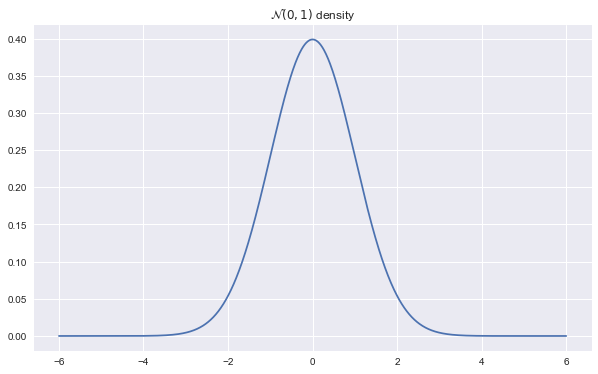

In [4]:
plt.plot(x, st.norm.pdf(x, mu, sd))
plt.title('$\mathcal{N}(0, 1)$ density');

At first we'll do approximate inference using ADVI

In [5]:
with model:
    advifit = pm.fit(method='advi')

Average Loss = 0.0024892: 100%|██████████| 10000/10000 [00:00<00:00, 11360.41it/s]
Finished [100%]: Average Loss = 0.0025053


In [6]:
def plot_density(approx, ax, **kwargs):
    ax.plot(x, st.norm.pdf(x, approx.mean.eval(), approx.std.eval()), **kwargs);

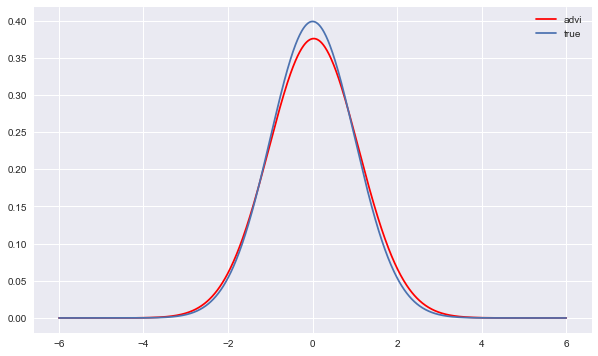

In [7]:
_, ax = plt.subplots()
plot_density(advifit, ax, color='r', label='advi')
ax.plot(x, st.norm.pdf(x, mu, sd), label='true');
ax.legend()

Densities seem to be similar enough. Let's try to use ASVGD

## Amortized Stein Variational Gradient Descent

This inference is based on Kernelized Stein Discrepancy
it's main idea is to move initial noisy particles so that
they fit target distribution best.

Algorithm is outlined below

*Input:* Parametrized random generator $R_{\theta}$, $n$ - number of samples from $R_{\theta}$

*Output:* $R_{\theta^{*}}$ that approximates the target distribution.

**On each iteration**

\begin{align*}
    \Delta x_i &= \hat{\phi}^{*}(x_i) \\
    \hat{\phi}^{*}(x) &= \frac{1}{n}\sum^{n}_{j=1}[k(x_j,x) \nabla_{x_j} logp(x_j)+ \nabla_{x_j} k(x_j,x)] \\
    \Delta_{\theta} &= \frac{1}{n}\sum^{n}_{i=1}\Delta x_i\frac{\partial x_i}{\partial \theta} \\
    \theta &\leftarrow \theta + \epsilon \Delta_{\theta}
\end{align*}

References
----------
-   Dilin Wang, Yihao Feng, Qiang Liu (2016)
    Learning to Sample Using Stein Discrepancy
    http://bayesiandeeplearning.org/papers/BDL_21.pdf

-   Dilin Wang, Qiang Liu (2016)
    Learning to Draw Samples: With Application to Amortized MLE for Generative Adversarial Learning
    arXiv:1611.01722

-   Yang Liu, Prajit Ramachandran, Qiang Liu, Jian Peng (2017)
    Stein Variational Policy Gradient
    arXiv:1704.02399

In [8]:
with model:
    inference = pm.ASVGD(pm.MeanField)

/Users/ferres/dev/pymc3/pymc3/variational/inference.py:63: UserWarning: You are using experimental inference Operator. It requires careful choice of temperature, default is 1. Default temperature works well for low dimensional problems and for significant `n_obj_mc`. Temperature > 1 gives more exploration power to algorithm, < 1 leads to undesirable results. Please take it in account when looking at inference result. Posterior variance is often **underestimated** when using temperature = 1.
  self.objective = op(approx, **op_kwargs)(tf)


To make you sure all is implemented correctly, at first I'll use computationaly heavy number of particles = 1000

In [9]:
inference.fit(
    200, 
    obj_n_mc=1000, 
    obj_optimizer=pm.sgd(learning_rate=1), # we do not need to run it long
    total_grad_norm_constraint=.1,
)

100%|██████████| 200/200 [00:25<00:00,  8.43it/s]


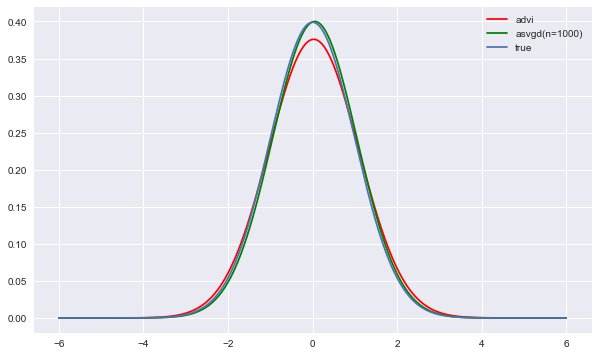

In [10]:
_, ax = plt.subplots()
plot_density(advifit, ax, color='r', label='advi')
plot_density(inference.approx, ax, color='g', label='asvgd(n=1000)')
ax.plot(x, st.norm.pdf(x, mu, sd), label='true');
ax.legend();

Seems it's all nice. Are you sure?? Next I'll use the same training scheme but with more iterations

In [11]:
with model:
    inference = pm.ASVGD(pm.MeanField)

/Users/ferres/dev/pymc3/pymc3/variational/inference.py:63: UserWarning: You are using experimental inference Operator. It requires careful choice of temperature, default is 1. Default temperature works well for low dimensional problems and for significant `n_obj_mc`. Temperature > 1 gives more exploration power to algorithm, < 1 leads to undesirable results. Please take it in account when looking at inference result. Posterior variance is often **underestimated** when using temperature = 1.
  self.objective = op(approx, **op_kwargs)(tf)


In [12]:
inference.fit(
    20000, 
    obj_n_mc=30, # much faster
    obj_optimizer=pm.sgd(learning_rate=.1), # we do not need to run it long
    total_grad_norm_constraint=.1,
)

100%|██████████| 20000/20000 [00:11<00:00, 1797.94it/s]


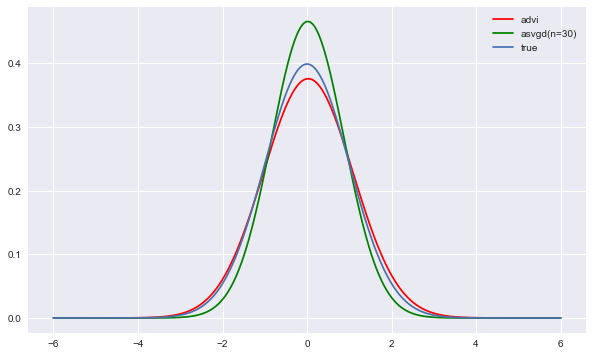

In [13]:
_, ax = plt.subplots()
plot_density(advifit, ax, color='r', label='advi')
plot_density(inference.approx, ax, color='g', label='asvgd(n=30)')
ax.plot(x, st.norm.pdf(x, mu, sd), label='true');
ax.legend();

Something wrong with variance. Maybe it's our learning rate is too high.

In [14]:
with model:
    inference = pm.ASVGD(pm.MeanField)
inference.fit(
    50000, 
    obj_n_mc=30, # much faster
    obj_optimizer=pm.sgd(learning_rate=.01),
    total_grad_norm_constraint=.01,
)

/Users/ferres/dev/pymc3/pymc3/variational/inference.py:63: UserWarning: You are using experimental inference Operator. It requires careful choice of temperature, default is 1. Default temperature works well for low dimensional problems and for significant `n_obj_mc`. Temperature > 1 gives more exploration power to algorithm, < 1 leads to undesirable results. Please take it in account when looking at inference result. Posterior variance is often **underestimated** when using temperature = 1.
  self.objective = op(approx, **op_kwargs)(tf)
100%|██████████| 50000/50000 [00:26<00:00, 1893.47it/s]


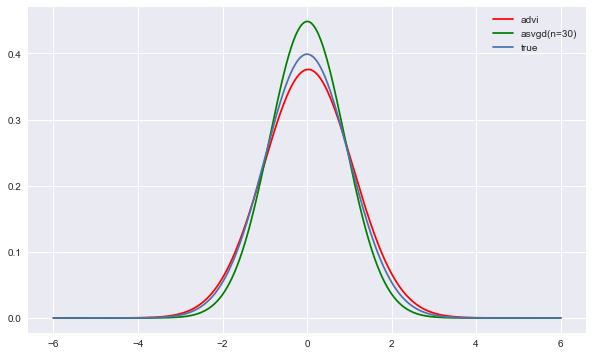

In [15]:
_, ax = plt.subplots()
plot_density(advifit, ax, color='r', label='advi')
plot_density(inference.approx, ax, color='g', label='asvgd(n=30)')
ax.plot(x, st.norm.pdf(x, mu, sd), label='true');
ax.legend();

Results are the same. What about tracking paramenters.

In [16]:
with model:
    inference = pm.ASVGD(pm.MeanField)

/Users/ferres/dev/pymc3/pymc3/variational/inference.py:63: UserWarning: You are using experimental inference Operator. It requires careful choice of temperature, default is 1. Default temperature works well for low dimensional problems and for significant `n_obj_mc`. Temperature > 1 gives more exploration power to algorithm, < 1 leads to undesirable results. Please take it in account when looking at inference result. Posterior variance is often **underestimated** when using temperature = 1.
  self.objective = op(approx, **op_kwargs)(tf)


In [17]:
tracker = pm.callbacks.Tracker(
    std=inference.approx.std.eval,
    mean=inference.approx.mean.eval
)
inference.fit(
    20000, 
    obj_n_mc=30, # much faster
    obj_optimizer=pm.adagrad(learning_rate=.1),
    total_grad_norm_constraint=.01,
    callbacks=[tracker]
)

100%|██████████| 20000/20000 [00:11<00:00, 1772.03it/s]


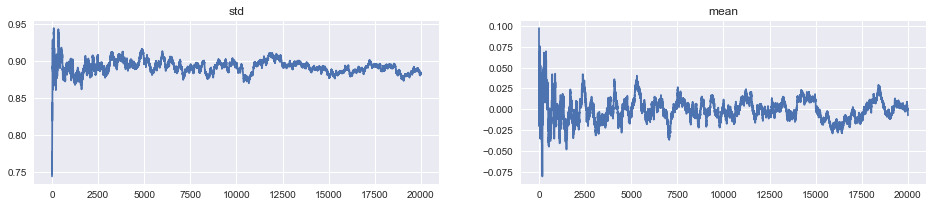

In [18]:
fig, ax, = plt.subplots(1, 2, figsize=(16, 3))
ax[0].plot(tracker['std'])
ax[0].set_title('std')
ax[1].plot(tracker['mean'])
ax[1].set_title('mean');

It does not seem that std is ever going to be 1

## Temperature magic
Previously algorithm was outlined without using temperature. Here I'll show how and why it fits there.

Recall $\sum^{n}_{j=1}[k(x_j,x) \nabla_{x_j} logp(x_j)]$. That part of Stein Gradient tends to move particles to the area with higher density.

And second one $\sum^{n}_{j=1}[\nabla_{x_j} k(x_j,x)]$ moves particles away from each other.

The main problem arizes when we have small number of particles ($n$) or when our dimensionality is relatively high to $n$. Diversive power of the second gradient part is too weak. We can scale it up with temperature. So algorithm is changed a bit

### ASVGD with temperature

*Input:* Parametrized random generator $R_{\theta}$, $n$ - number of samples from $R_{\theta}$, temperature $T$

*Output:* $R_{\theta^{*}}$ that approximates the target distribution.

**On each iteration**

$
\begin{align*}
    \Delta x_i &= \hat{\phi}^{*}(x_i) \\
    \hat{\phi}^{*}(x) &= \frac{1}{n}\sum^{n}_{j=1}[\color{red}{\frac{1}{T}}k(x_j,x) \nabla_{x_j} logp(x_j)+ \nabla_{x_j} k(x_j,x)] \\
    \Delta_{\theta} &= \frac{1}{n}\sum^{n}_{i=1}\Delta x_i\frac{\partial x_i}{\partial \theta} \\
    \theta &\leftarrow \theta + \epsilon \Delta_{\theta}
\end{align*}
$

Thus higher temperature leads to more diversive posterior

## Experiments
It is easy to set up temperature for ASVGD (as well as SVGD) in PyMC3, we can change it in experiments and plot results

In [19]:
import warnings
warnings.filterwarnings('ignore')
import tqdm
temperatures = np.linspace(.9, 2., 30)
trackers = []
approxes = []
progress = tqdm.tqdm(temperatures)
with progress:
    for t in progress:
        inference = pm.ASVGD(pm.MeanField, temperature=t, model=model)
        tracker = pm.callbacks.Tracker(
            std=inference.approx.std.eval,
            mean=inference.approx.mean.eval)
        approx = inference.fit(
            20000, 
            obj_n_mc=30, # default setup
            obj_optimizer=pm.adagrad(learning_rate=.1),
            total_grad_norm_constraint=.01,
            progressbar=False,
            callbacks=[tracker]
        )
        trackers.append(tracker)
        approxes.append(approx)

100%|██████████| 30/30 [06:06<00:00, 13.08s/it]


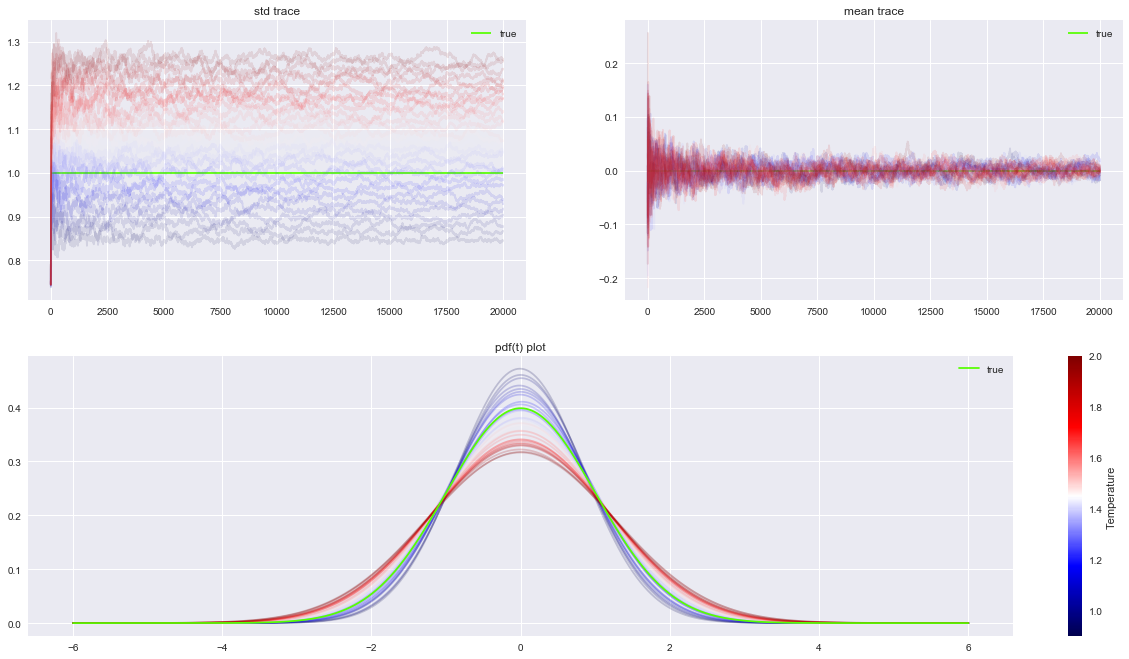

In [20]:
fig = plt.figure(figsize=(16,9))
fig.subplots_adjust(bottom=0.025, left=0.025, top = 0.975, right=0.975)
cmap_ = plt.get_cmap('seismic')
cmap = lambda t: cmap_((t-.9)/(2-.9))
ax = []
for nrows, ncols, plot_number in [(2, 1, 2), (2, 2, 1), (2, 2, 2)]:
    ax.append(fig.add_subplot(nrows, ncols, plot_number))

for t, tracker, approx in zip(temperatures, trackers, approxes):
    plot_density(approx, ax[0], color=cmap(t), alpha=.2)
    ax[1].plot(tracker['std'], color=cmap(t), alpha=.1)
    ax[2].plot(tracker['mean'], color=cmap(t), alpha=.1)
ax[0].plot(x, st.norm.pdf(x, mu, sd), label='true', color='#56ff00')
ax[1].hlines(1, 0, 20000, label='true', color='#56ff00')
ax[2].hlines(0, 0, 20000, label='true', color='#56ff00')
ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[0].set_title('pdf(t) plot')
ax[1].set_title('std trace')
ax[2].set_title('mean trace')
sm = plt.cm.ScalarMappable(cmap=cmap_, norm=plt.Normalize(vmin=.9, vmax=2))
sm._A = []
plt.colorbar(sm, ax=ax[0], fraction=.05, label='Temperature');

Seems like temperature can drasically change our results. And obviously $T=1$ is not the best choice even for this easy problem.

In [21]:
with model:
    inference = pm.ASVGD(pm.MeanField, temperature=1.3)
    inference1 = pm.ASVGD(pm.MeanField, temperature=1)
inference.fit(
    5000, 
    obj_n_mc=30,
    obj_optimizer=pm.adagrad(learning_rate=.1),
    total_grad_norm_constraint=.01,
)
inference1.fit(
    5000, 
    obj_n_mc=30,
    obj_optimizer=pm.adagrad(learning_rate=.1),
    total_grad_norm_constraint=.01,
)

100%|██████████| 5000/5000 [00:03<00:00, 1536.30it/s]


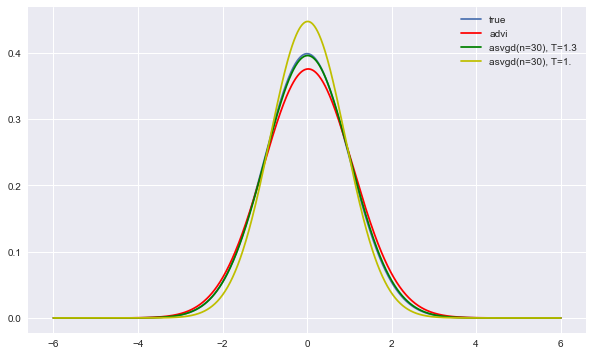

In [22]:
_, ax = plt.subplots()
ax.plot(x, st.norm.pdf(x, mu, sd), label='true');
plot_density(advifit, ax, color='r', label='advi')
plot_density(inference.approx, ax, color='g', label='asvgd(n=30), T=1.3')
plot_density(inference1.approx, ax, color='y', label='asvgd(n=30), T=1.')
ax.legend();

Best choice fot $T$ given this problem and $n=30$ particles was 1.3! I have no intuition about how to choose this $T$ for other problems and not tractable posteriors. That's a good field for research.